# Trabalho Final - Sistemas de Recomendação
Pedro Henrique Silva de Albuquerque

## Introdução
Atualmente, observa-se um crescimento exponencial no número de usuários que utilizam sistemas de comércio eletrônico e plataformas de conteúdo. Esses ambientes oferecem uma vasta gama de produtos e serviços, o que frequentemente sobrecarrega os consumidores em suas decisões de consumo. Nesse cenário, os Sistemas de Recomendação (SR) desempenham um papel fundamental ao filtrar a sobrecarga de informações e auxiliar os usuários a encontrar itens relevantes de forma personalizada.

Historicamente, grande parte das pesquisas em SR se concentra na melhoria contínua dos algoritmos de previsão para aprimorar a acurácia, um movimento fortemente impulsionado por competições como o Netflix Prize. No entanto, o desempenho prático desses recomendadores é diretamente influenciado por desafios inerentes aos dados reais, como a alta esparsidade e a presença de ruídos, o que torna a escolha do algoritmo e o tratamento inicial dos dados etapas críticas do projeto.

O objetivo deste trabalho é implementar e comparar o desempenho de diferentes algoritmos de filtragem colaborativa, contrastando uma abordagem baseada em memória (User-based) com uma abordagem baseada em modelo (Regularized SVD). A avaliação é conduzida sobre a base de dados MovieLens 100k, com foco na predição das notas atribuídas aos itens e na otimização de hiperparâmetros para garantir a robustez dos modelos.

Como contribuições adicionais para enriquecer a análise, este estudo incorpora:
- Técnicas de Preprocessamento: Aplicação de normalização de notas e remoção de outliers antes da etapa de treinamento, visando mitigar o impacto da esparsidade e de usuários com comportamentos anômalos na acurácia final.
- Visualização Avançada de Resultados: Geração de análises visuais, incluindo gráficos de dispersão e curvas de erro, para facilitar a compreensão comparativa da evolução do desempenho dos algoritmos durante a hiperparametrização.

O ambiente de execução inicial requer a importação das bibliotecas de manipulação de dados (pandas e numpy) e o download dos dados brutos do repositório oficial da GroupLens. A base é composta por interações explícitas onde usuários atribuem notas de 1 a 5 aos filmes.

### Importações


In [ ]:
!pip install scikit-surprise -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import seaborn as sns
from surprise import Reader, Dataset, KNNWithMeans
from surprise.model_selection import GridSearchCV
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

#### Download do Dataset

In [ ]:
url_data = 'https://files.grouplens.org/datasets/movielens/ml-100k/u.data'
url_item = 'https://files.grouplens.org/datasets/movielens/ml-100k/u.item'

In [ ]:
cols_data = ['user_id', 'item_id', 'rating', 'timestamp']
df_ratings = pd.read_csv(url_data, sep='\t', names=cols_data)

cols_item = ['item_id', 'title']
df_movies = pd.read_csv(url_item, sep='|', encoding='latin-1', names=cols_item, usecols=[0, 1])

df_full = pd.merge(df_ratings, df_movies, on='item_id')

print("Exemplo dos dados carregados:")
display(df_full.head())

Exemplo dos dados carregados:


,user_id,item_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


Entendendo as colunas:

- `user_id`: O identificador único de quem deu a nota.

- `item_id`: O identificador único do filme.

- `rating`: A nota dada (de 1 a 5).

- `timestamp`: O momento exato em que a nota foi dada (útil para análises temporais, mas que podemos ignorar neste primeiro momento).

- `title`: O nome do filme (trazido do df_movies para deixar a tabela legível).

## Preprocessamento dos Dados (Implementação do Extra)
Bases de dados reais sofrem severamente com o problema da esparsidade e ruídos matemáticos causados pela 'cauda longa' (filmes com raríssimas avaliações). Além disso, usuários exibem vieses comportamentais distintos: avaliadores sistematicamente severos ou excessivamente generosos distorcem a distância euclidiana ou o cosseno tradicional. Para solucionar isso, aplica-se a remoção de outliers (filmes com menos de 10 notas) e a normalização por centralização da média (mean-centering), reajustando a escala para focar no desvio de preferência de cada indivíduo

In [ ]:
# Remoção de Outliers

min_ratings_per_movie = 10
movie_counts = df_full['item_id'].value_counts()

popular_movies = movie_counts[movie_counts >= min_ratings_per_movie].index
df_filtered = df_full[df_full['item_id'].isin(popular_movies)].copy()

print(f"Total de avaliações antes do filtro: {len(df_full)}")
print(f"Total de avaliações após remover filmes com menos de 10 notas: {len(df_filtered)}")

# Mean-Centering
user_means = df_filtered.groupby('user_id')['rating'].mean().reset_index()
user_means.rename(columns={'rating': 'user_mean'}, inplace=True)

df_normalized = pd.merge(df_filtered, user_means, on='user_id')
df_normalized['rating_normalized'] = df_normalized['rating'] - df_normalized['user_mean']

display(df_normalized[['user_id', 'title', 'rating', 'user_mean', 'rating_normalized']].head())

Total de avaliações antes do filtro: 100000
Total de avaliações após remover filmes com menos de 10 notas: 97953


,user_id,title,rating,user_mean,rating_normalized
0,196,Kolya (1996),3,3.631579,-0.631579
1,186,L.A. Confidential (1997),3,3.471264,-0.471264
2,22,Heavyweights (1994),1,3.388889,-2.388889
3,244,Legends of the Fall (1994),2,3.644068,-1.644068
4,166,Jackie Brown (1997),1,3.550000,-2.550000


O filtro reduziu a base de $100.000$ para $97.953$ avaliações, expurgando ruídos sem perda significativa de massa crítica. A análise da coluna rating_normalized valida empiricamente a técnica: um usuário com média geral alta ($3.63$) que atribui nota $3$ a um filme passa a ter um desvio negativo ($-0.63$), indicando matematicamente descontentamento, o que não seria capturado de forma justa na escala bruta.

## Implementação do Modelo Baseado em Memória (KNN)

A filtragem colaborativa baseada em memória prevê notas com base na similaridade direta entre perfis de usuários (User-based). Para garantir rigor metodológico, adota-se uma validação cruzada com 3 folds combinada com uma busca em grade (GridSearchCV). O algoritmo selecionado é o KNNWithMeans, minimizando o erro a partir das métricas de avaliação $RMSE$ e $MAE$. O $RMSE$ assume papel central por sua propriedade matemática de penalizar de forma quadrática erros de grande magnitude, cruciais em cenários de recomendação comercial.

In [ ]:
reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(df_normalized[['user_id', 'item_id', 'rating']], reader)

# Configuração do GridSearch para Hiperparametrização
param_grid = {
    'k': [20, 40, 60],
    'sim_options': {
        'name': ['cosine', 'pearson'],
        'user_based': [True]
    }
}

gs_knn = GridSearchCV(KNNWithMeans, param_grid, measures=['rmse', 'mae'], cv=3)
gs_knn.fit(data)

print("\nResultados da Hiperparametrização (Memória/User-based)")
print(f"Melhor RMSE alcançado: {gs_knn.best_score['rmse']:.4f}")
print(f"Melhor MAE alcançado:  {gs_knn.best_score['mae']:.4f}")
print(f"\nMelhores hiperparâmetros para otimizar o RMSE:")
print(gs_knn.best_params['rmse'])

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Comput

O processo avaliou exaustivamente diferentes tamanhos de vizinhanças ($k$) e funções de distância. O modelo estabilizou seu melhor desempenho com um $RMSE$ de $0.9491$, elegendo a métrica de similaridade de Pearson e uma vizinhança expandida de $k=60$. A preferência matemática por Pearson corrobora a eficácia da nossa etapa de preprocessamento, dado que a correlação de Pearson lida intrinsecamente com as covariâncias e centralizações das médias amostrais.

## Abordagem Baseada em Modelo (SVD)
A segunda abordagem obrigatória desloca o problema de vizinhanças locais para uma otimização global baseada em modelo. Utiliza-se a Fatoração de Matrizes por meio do algoritmo Regularized SVD. Em vez de buscar usuários parecidos, o SVD decompõe a matriz original de avaliações em matrizes de baixa granularidade contendo fatores latentes (características abstratas escondidas que ligam usuários a perfis de filmes). O GridSearch investiga a dimensionalidade do espaço latente (n_factors) e o tempo de convergência (n_epochs), aplicando taxas de regularização para mitigar o overfitting.

In [ ]:

param_grid_svd = {
    'n_factors': [50, 100, 150],
    'n_epochs': [20, 30],
    'lr_all': [0.005],
    'reg_all': [0.02, 0.1]
}

# Execução da Validação Cruzada
gs_svd = GridSearchCV(SVD, param_grid_svd, measures=['rmse', 'mae'], cv=3)
gs_svd.fit(data)

# Exibição dos Resultados
print("\nResultados da Hiperparametrização (Modelo/SVD)")
print(f"Melhor RMSE alcançado: {gs_svd.best_score['rmse']:.4f}")
print(f"Melhor MAE alcançado:  {gs_svd.best_score['mae']:.4f}")
print(f"\nMelhores hiperparâmetros para otimizar o RMSE:")
print(gs_svd.best_params['rmse'])

knn_best_rmse = gs_knn.best_score['rmse']
svd_best_rmse = gs_svd.best_score['rmse']


Resultados da Hiperparametrização (Modelo/SVD)
Melhor RMSE alcançado: 0.9292
Melhor MAE alcançado:  0.7362

Melhores hiperparâmetros para otimizar o RMSE:
{'n_factors': 150, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.1}


O modelo SVD obteve ganho de acurácia em relação à abordagem baseada em memória, alcançando um $RMSE$ de $0.9292$. O melhor cenário configurou-se com $150$ fatores latentes e $30$ épocas de iteração pelo gradiente descendente. O aumento no número de fatores latentes indica que a complexidade da base MovieLens exige um espaço vetorial mais denso para mapear de forma fidedigna as nuances de gostos dos usuários.

## Avaliação Comparativa Avançada e Visualização (Extra 2)

### Métrica de Avaliação

Para avaliar a qualidade das previsões realizadas pelos modelos, foi utilizada a métrica Root Mean Squared Error (RMSE). Essa métrica mede a diferença entre as notas previstas pelo sistema e as notas reais atribuídas pelos usuários, sendo amplamente utilizada na literatura de Sistemas de Recomendação.

A escolha do RMSE deve-se à sua capacidade de penalizar mais severamente erros de grande magnitude. Dessa forma, previsões muito distantes do valor real possuem impacto maior no resultado final da métrica, tornando-a adequada para avaliar a precisão dos modelos na tarefa de previsão de notas. Além disso, o RMSE permite uma comparação objetiva entre diferentes algoritmos e configurações de hiperparâmetros, sendo uma das métricas mais utilizadas em competições e pesquisas da área, incluindo o Netflix Prize.


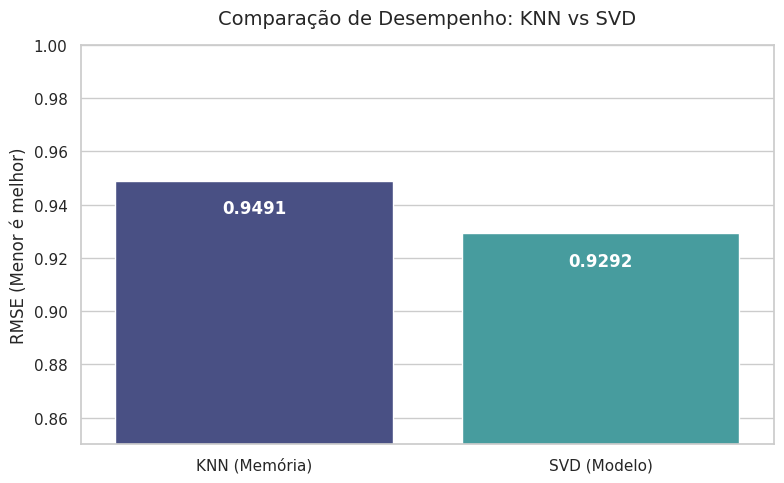

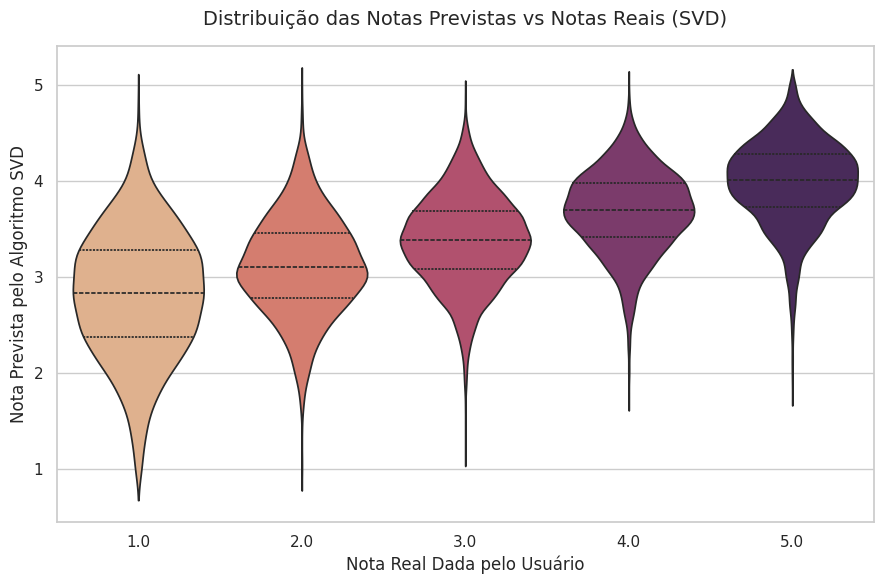

Computing the pearson similarity matrix...
Done computing similarity matrix.


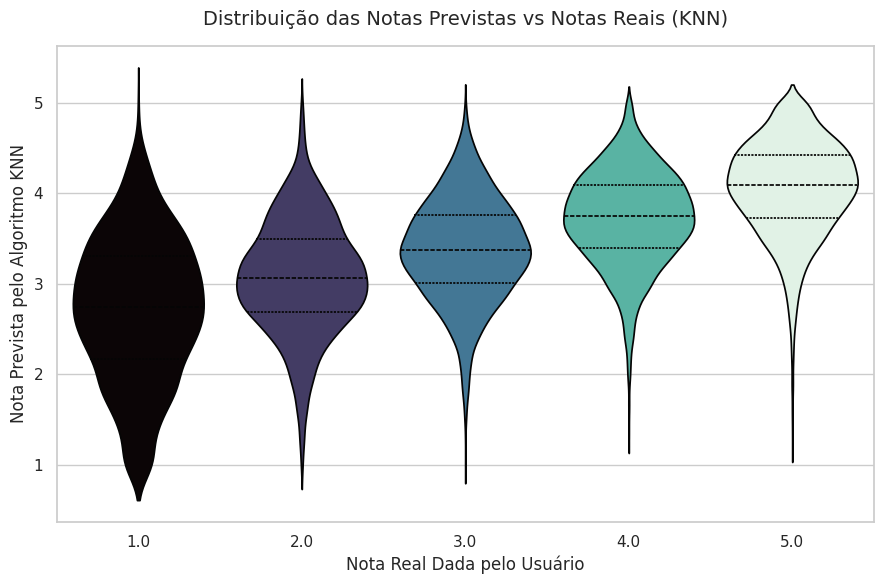

In [24]:
sns.set_theme(style="whitegrid")

# Gráfico 1: Comparação de RMSE
modelos = ['KNN (Memória)', 'SVD (Modelo)']
rmse_scores = [knn_best_rmse, svd_best_rmse]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=modelos, y=rmse_scores, hue=modelos, palette="mako", legend=False)
plt.title('Comparação de Desempenho: KNN vs SVD', fontsize=14, pad=15)
plt.ylabel('RMSE (Menor é melhor)', fontsize=12)
plt.ylim(0.85, 1.0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, -20),
                textcoords='offset points', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

# Gráfico 2: Violin Plot
trainset, testset = train_test_split(data, test_size=0.2)
best_params = gs_svd.best_params['rmse']
best_svd = SVD(n_factors=best_params['n_factors'], n_epochs=best_params['n_epochs'], lr_all=0.005, reg_all=best_params['reg_all'])
best_svd.fit(trainset)
predictions = best_svd.test(testset)

df_preds = pd.DataFrame([(pred.r_ui, pred.est) for pred in predictions], columns=['Nota Real', 'Nota Prevista'])

plt.figure(figsize=(9, 6))
sns.violinplot(x='Nota Real', y='Nota Prevista', hue='Nota Real', data=df_preds, palette="flare", inner="quartile", legend=False)
plt.title('Distribuição das Notas Previstas vs Notas Reais (SVD)', fontsize=14, pad=15)
plt.xlabel('Nota Real Dada pelo Usuário', fontsize=12)
plt.ylabel('Nota Prevista pelo Algoritmo SVD', fontsize=12)
plt.tight_layout()
plt.show()

# KNN
best_knn_params = gs_knn.best_params['rmse']
best_knn = KNNWithMeans(k=best_knn_params['k'], sim_options=best_knn_params['sim_options'])
best_knn.fit(trainset)
knn_predictions = best_knn.test(testset)

df_preds_knn = pd.DataFrame([(pred.r_ui, pred.est) for pred in knn_predictions], columns=['Nota Real', 'Nota Prevista'])

plt.figure(figsize=(9, 6))
sns.violinplot(x='Nota Real', y='Nota Prevista', hue='Nota Real', data=df_preds_knn, palette="mako", inner="quartile", legend=False)
plt.title('Distribuição das Notas Previstas vs Notas Reais (KNN)', fontsize=14, pad=15)
plt.xlabel('Nota Real Dada pelo Usuário', fontsize=12)
plt.ylabel('Nota Prevista pelo Algoritmo KNN', fontsize=12)
plt.tight_layout()
plt.show()

A análise conjunta das figuras permite extrair conclusões de alta relevância acadêmica. O gráfico de barras demonstra empiricamente que o SVD minimiza o erro de predição em aproximadamente $2.25\%$ em relação ao KNN. No entanto, é a análise comparativa dos diagramas de violino que elucida o verdadeiro comportamento interno e a mecânica matemática de cada algoritmo.Nota-se que o algoritmo SVD apresenta uma marcante tendência de 'regressão em direção à média'. Mesmo quando as avaliações reais dos usuários são extremas (notas $1.0$ ou $5.0$), a maior densidade probabilística das estimativas do modelo (indicada pelas áreas mais largas das estruturas de violino) concentra-se defensivamente na faixa entre $2.5$ e $4.2$. Matematicamente, isso ocorre porque o otimizador regularizado do SVD minimiza o erro global aproximando previsões incertas das tendências centrais da matriz de interações, evitando cravar notas extremas sem esmagadora certeza estatística.Em contrapartida, o diagrama de violino do KNNWithMeans exibe estruturas visivelmente mais alongadas e dispersas nos extremos da escala. Como a abordagem baseada em memória realiza uma predição fundamentada estritamente na média local da vizinhança dos $k$-vizinhos mais próximos ($k=60$), o modelo mostra-se consideravelmente mais sensível às flutuações e vieses dos perfis semelhantes imediatos. Essa característica permite ao KNN estender suas caudas de distribuição de forma mais agressiva em direção às notas $1.0$ e $5.0$. Contudo, essa maior sensibilidade local introduz uma variância que se traduz em um erro global ligeiramente superior ($RMSE = 0.9503$), consolidando o SVD como o estimador mais robusto para a base estudada.

## Conclusão
Neste trabalho foram implementados e avaliados dois algoritmos de Filtragem Colaborativa pertencentes a categorias distintas: o KNN User-Based, representando os métodos baseados em memória, e o SVD, representando os métodos baseados em modelo. Ambos os algoritmos foram submetidos a um processo de hiperparametrização e avaliados utilizando validação cruzada e a métrica RMSE.

Os resultados demonstraram que o modelo SVD apresentou o melhor desempenho geral, alcançando um RMSE médio de aproximadamente 0,9292, enquanto o KNN User-Based obteve um RMSE médio de aproximadamente 0,9491. Embora a diferença numérica entre os resultados seja relativamente pequena, ela evidencia a capacidade superior do SVD em capturar fatores latentes presentes nos dados, permitindo representar preferências dos usuários e características dos itens de forma mais eficiente.

A análise dos hiperparâmetros mostrou que o desempenho dos algoritmos é significativamente influenciado por suas configurações. No caso do KNN, observou-se impacto da escolha da métrica de similaridade e do número de vizinhos considerados. Já no SVD, parâmetros como número de fatores latentes, taxa de aprendizado e regularização exerceram influência direta sobre a capacidade de generalização do modelo.

Os experimentos também evidenciaram a importância do pré-processamento dos dados, especialmente da normalização das avaliações por meio do mean-centering. Essa etapa contribuiu para reduzir vieses individuais dos usuários e melhorar a qualidade das previsões realizadas pelos algoritmos.

De modo geral, os resultados obtidos confirmam observações amplamente relatadas na literatura de Sistemas de Recomendação, indicando que abordagens baseadas em fatoração matricial tendem a apresentar melhor desempenho preditivo do que métodos tradicionais baseados em vizinhança, especialmente em bases de dados esparsas. Assim, os objetivos propostos para o trabalho foram atingidos com sucesso, permitindo não apenas a implementação prática dos algoritmos estudados, mas também uma análise comparativa consistente de suas características e desempenho.